In [57]:
from dataImporter import *
from experiment import *
from utilityFunctions import *
from tsFeatures import *
from afterAnalysis import *
from visualization import *
from itertools import combinations
import time

In [58]:
import heapq
import re

class botumUpSearch:
    
    def __init__(self,df,distance_matrix,number_of_row_pairs,depth,q,nr_chunks=5,min_coverage_perc=0.01,min_coverage_abs=3):
    
        self.matrix = distance_matrix
        self.x = number_of_row_pairs
        self.d = depth
        self.df = df.copy()
        self.df_org = df.copy()
        self.q = q
        self.min_coverage_perc = min_coverage_perc
        self.min_coverage_abs = min_coverage_abs
        self.nr_chunks = nr_chunks
        
        # steps to partition numerical columns into bins
        for col in self.df.columns:
            if (self.df[col].dtype == 'float64') or (self.df[col].dtype == 'float32') or (self.df[col].dtype == 'int64'):
                dat = np.sort(self.df[col])
                dat = dat[np.logical_not(np.isnan(dat))]
                for i in range(1, self.nr_chunks+1):
                    # determine the number of chunks you want to divide your data in
                    x = np.percentile(dat, (i-1)*100/self.nr_chunks)  #
                    y = np.percentile(dat, (i)*100/self.nr_chunks)
                    candidate = "{} <= {} <= {}".format(x ,col, y)
                    self.df[col] = self.df[col].apply(lambda val: candidate if (not isinstance(val, str) and x <= val <= y) else val)
            
            
    def find_min_indices(matrix, x):
        """
        Finds the x smallest distances and returns tuples of the indexes i and j.
        
        matrix = distance matrix
        x = number of pairs we want to find
        """
        
        min_heap = []
        n = len(matrix)

        for i in range(n):
            for j in range(i+1, n):
                if len(min_heap) < x:
                    heapq.heappush(min_heap, (-matrix[i][j], (i, j)))
                else:
                    if matrix[i][j] < -min_heap[0][0]:
                        heapq.heappop(min_heap)
                        heapq.heappush(min_heap, (-matrix[i][j], (i, j)))

        return [idx for val, idx in min_heap]


    def get_common_attributes(rows, d_len):
        """
        Finds the attribute value combinations that are similar in all rows.

        rows = list of rows of a dataframe
        d_len = description length
        """

        common_attributes = []
        attribute_combinations = combinations(rows[0].items(), d_len)

        for combination in attribute_combinations:
            attributes = [f"{attribute} == '{value}'" for attribute, value in combination]
            if all(all(row.get(attribute) == value for attribute, value in combination) for row in rows[1:]):
                common_attributes.append(attributes)
                
        # print("common_attributes = ", common_attributes)

        return common_attributes


    
    def get_unique_lists(list_of_lists):
        """
        Filters redundant descriptions, when they are exactly the same or in a different order.
        """
        
        unique_lists = [list(x) for x in set(tuple(set(sublist)) for sublist in list_of_lists)]
        return unique_lists
    
    def generate_new_tuples(tuples_list, matrix):
        z = len(tuples_list[0])  # Size of the tuples in the original list
        new_tuples_list = []

        for t in tuples_list:
            new_tuples = []

            for index in t:
                row = index
                new_tuple = list(t)  # Create a new tuple based on the existing one

                # Find the minimum value in the row that satisfies the conditions
                min_val = float('inf')
                min_index = None
                for i, val in enumerate(matrix[row]):
                    if val < min_val and i != row and i not in t:
                        min_val = val
                        min_index = i

                new_tuple.append(min_index)  # Add the new index to the tuple
                new_tuples.append(tuple(new_tuple))  # Convert the list back to a tuple and add it to the new list

            new_tuples_list.extend(new_tuples)

        return new_tuples_list   

    
    def findQuality(self, quality_measure = cluster_based_quality_measure, z=3,comparison_type = "complement" ,size_corr = no_size_corr):
        
        self.running_time = time.time()
        self.quality_measure = quality_measure
        self.size_corr = size_corr
        self.quality_measure_counter = 0
        self.comparison_type = comparison_type
        self.z = z
        z=z-2
        
        
        min_heap = []
        len_df = len(self.df)
        
        promising_combinations = botumUpSearch.find_min_indices(self.matrix, self.x)
        print('promising_combinations_start step= ',len(promising_combinations))
        
        promising_combinations_larger_size = promising_combinations
        if z>0:
            for i in range(z):
                promising_combinations_larger_size = botumUpSearch.generate_new_tuples(promising_combinations_larger_size, self.matrix)
             
        print('promising_combinations_mid step= ',len(promising_combinations_larger_size))   
        promising_combinations_larger_size_unique = [tuple(s) for s in {frozenset(t) for t in promising_combinations_larger_size}]
        promising_combinations = promising_combinations_larger_size_unique
        
        print('promising_combinations_large= ',len(promising_combinations))
        
        

        #TODO in line below it only works when target attribute is the last attribute
        
        candidate_descriptions = [botumUpSearch.get_common_attributes([self.df.iloc[i][:-1] for i in index_tuple],d) for index_tuple in promising_combinations for d in range(1,self.d+1)]
        print('descriptions',len(candidate_descriptions))

        # unique_candidate_descriptions gives the unique potential candidate descriptions
        unique_candidate_descriptions = botumUpSearch.get_unique_lists([item for sublist in candidate_descriptions for item in sublist])
        
        print('unique descriptions',len(unique_candidate_descriptions))

        for desc in unique_candidate_descriptions:
            ind = self.df.query(as_string(desc))
            
            #checks if subgroups comply with size constrains
            if satisfies_all(desc, ind, len_df, self.min_coverage_perc, self.min_coverage_abs):
                
                quality, coverage = eval_quality(ind, self.df, 'target', self.quality_measure, comparison_type,distance_matrix=self.matrix,correct_for_size=size_corr)
                self.quality_measure_counter += 1
                
                if len(min_heap) < self.q:
                    heapq.heappush(min_heap, (quality, desc, coverage))
                    #heapq.heapify(min_heap)
                else:
                    
                    if -quality < -heapq.nsmallest(1, min_heap)[0][0]:

                        equal_quals = [i for i, x in enumerate(min_heap) if x[0] == quality]
                        
                        # checks if set of records isn't already present as a result of a different description
                        if len(equal_quals)>0:
                            for i in equal_quals:
                                comp = self.df.query(as_string(min_heap[i][1]))
                                if np.array_equal(comp.index, ind.index):
                                    pass
                                else:
                                    heapq.heappushpop(min_heap, (quality, desc, coverage))
                        else:
                            heapq.heappushpop(min_heap, (quality, desc, coverage))

        
        self.running_time = time.time() - self.running_time
        
        self.result = sorted(min_heap, key=lambda x: x[0], reverse=True)
        
        
        #part that changes the numerical propositions back into a evaluatable thing instead of a string
        data = bus.result
        for i, (value1, sublist, value2) in enumerate(data):
            for j, string in enumerate(sublist):
                
                if any(op in string for op in ['<', '<=', '>', '>=']):
                    # Extract the nested string without the outer quotes
                    try:
                        nested_string = string.split("'")[1]
                     # Replace the string with the extracted nested string
                        sublist[j] = nested_string
                    except:
                        pass
             # Update the modified sublist in the data
            data[i] = ( value1, sublist,value2)
            
        
        self.result = data
        self.quals = [i[0] for i in min_heap]
        self.covs = [i[2] for i in min_heap]
        self.avg_quality = sum(self.quals)/len(self.quals)
        self.avg_coverage = sum(self.covs)/len(self.covs)
        self.descs = [i[1] for i in min_heap]
        
    def print_outcome(self):
        
        print('after checking ',self.quality_measure_counter,' potential subgroups, in ',round(self.running_time,3),' seconds')
        print('Outcome of bottumUpSearch is:')
        print(' ')
        print('avg_quality = ',round(self.avg_quality,3))
        print('max_quality = ',round(max(self.quals),3))
        print(' ')
        print('avg_coverage = ',round(self.avg_coverage,3))
        print('max_coverage = ',round(max(self.covs),3))
        print(' ')
                
        for z in self.result:
            conjunction = " Ʌ ".join(["(" + condition.replace(" == ", "=").strip() + ")" for condition in z[1]])
            print('description =',conjunction)
            print('quality =',round(z[0],3))
            print('coverage =',round(z[2],3))
            print(' ')
            
    def statistical_test(self,k,save_title="./temp_statistical_test_results.pkl"):
        
        """
        Creates quality measure outputs of k randomized experiments 
        to use for statistical testing of the original output.
        """
        
        bus_df = self.df.reset_index(drop=True)

        results = []

        for _ in range(k):
            
            matrix = botumUpSearch.randomize_symmetric_matrix(self.matrix)

            bus_rand = botumUpSearch(bus_df, matrix, self.x, self.d, 1,
                                     nr_chunks=self.nr_chunks, min_coverage_perc=self.min_coverage_perc,
                                     min_coverage_abs=self.min_coverage_abs)
            bus_rand.findQuality(quality_measure = self.quality_measure, z=self.z, 
                                 comparison_type = self.comparison_type , size_corr = self.size_corr)
            res = bus_rand.quals
            results = results+res
        
            self.random_output = results
            
        pvalues = []
        for x in self.quals:
            empirical_p_value = (sum([(comp > x) for comp in self.random_output])+0.5*sum([(comp == x) for comp in self.random_output])+1)/(len(self.random_output)+1)
            pvalues.append(empirical_p_value)
        self.pvalues = pvalues
        
        print('after checking ',self.quality_measure_counter,' potential subgroups')
        print('Outcome of bottumUpSearch is:')
        print(' ')
        print('avg_quality = ',round(self.avg_quality,3))
        print('max_quality = ',round(max(self.quals),3))
        print(' ')
        print('avg_coverage = ',round(self.avg_coverage,3))
        print('max_coverage = ',round(max(self.covs),3))
        print(' ')
            
        p=0
        for z in self.result:
            
            conjunction = " Ʌ ".join(["(" + condition.replace(" == ", "=").strip() + ")" for condition in z[1]])
            print('description =',conjunction)
            print('quality =',round(z[0],3)," with p-value= ",round(self.pvalues[p],4))
            print('coverage =',round(z[2],3))
            print(' ')
            p+=1
        to_be_saved = [0,0]
        to_be_saved[0] = self.pvalues
        to_be_saved[1] = self.random_output

        np.save(save_title, to_be_saved)
        
    
    def save(self, title, **kwargs):
        
        self.title = title
            
        try:
            pickle_results = pd.read_pickle('results_hierarchical.pkl')
        except:
            pickle_results = pd.DataFrame(columns=['title', 'running_time', "subgroups_checked", 'descs', 'avg_quality', 'avg_coverage',
                                                   'quality_measure', 'x', 'd', 'q',
                                                   'correct_for_size_var', 'result'])

        pickle_results.loc[len(pickle_results)] = [self.title, self.running_time, self.quality_measure_counter, self.descs, self.avg_quality, self.avg_coverage,
                                                   self.quality_measure, self.x, self.d, self.q,
                                                   self.size_corr, self.result]

        pickle_results.to_pickle('results_hierarchical.pkl')
        
        try:
            try:
                pickle_results = pd.read_pickle('random_results_hierarchical.pkl')
            except:
                pickle_results = pd.DataFrame(columns=['title', 'p-values','results'])

            pickle_results.loc[len(pickle_results)] = [self.title, self.pvalues, self.random_output]

            pickle_results.to_pickle('random_results_hierarchical.pkl')
        except:
            pass

        

In [59]:
df_original, cat, num, features = getData("Stock5YSmall",countries='large_economies',attributes='expertBased')
df = df_original.copy()

In [60]:
df_test = df
df_test = df_test.reset_index(drop=True)

In [61]:
euclidean_slope_distance_matrix = np.load('euclidean_slope_distance_matrix.npy')

In [9]:
descs = [["currency == 'EUR'",
  '59721.0 <= fullTimeEmployees <= 2300000.0',
  "exchange == 'FRA'"],
 ['131.653 <= debtToEquity <= 219.757',
  '7222688665.6 <= marketCap <= 24683085572.046852'],
 ['24683085572.046852 <= marketCap <= 1.0602763499077632e+16',
  "exchange == 'NYQ'"],
 ['24683085572.046852 <= marketCap <= 1.0602763499077632e+16',
  "currency == 'USD'",
  '59721.0 <= fullTimeEmployees <= 2300000.0'],
 ["currency == 'USD'",
  "exchangeTimezoneName == 'America/New_York'",
  '59721.0 <= fullTimeEmployees <= 2300000.0'],
 ["currency == 'USD'", '59721.0 <= fullTimeEmployees <= 2300000.0'],
 ["currency == 'EUR'", '59721.0 <= fullTimeEmployees <= 2300000.0'],
 ['131.653 <= debtToEquity <= 219.757',
  '11.3453 <= enterpriseToEbitda <= 15.523'],
 ['15.523 <= enterpriseToEbitda <= 24.745400000000004',
  "sector == 'Real Estate'"],
 ["country == 'United States'",
  "sector == 'Financial Services'",
  "exchange == 'NYQ'"],
 ["sector == 'Financial Services'",
  '7222688665.6 <= marketCap <= 24683085572.046852'],
 ['59721.0 <= fullTimeEmployees <= 2300000.0', "country == 'France'"],
 ['7222688665.6 <= marketCap <= 24683085572.046852',
  '8.416799999999999 <= enterpriseToEbitda <= 11.3453'],
 ['59721.0 <= fullTimeEmployees <= 2300000.0',
  '824162.0000000006 <= averageVolume10days <= 489560408.0'],
 ['24683085572.046852 <= marketCap <= 1.0602763499077632e+16',
  "exchangeTimezoneName == 'America/New_York'",
  '59721.0 <= fullTimeEmployees <= 2300000.0'],
 ['21760.0 <= fullTimeEmployees <= 59721.0', "sector == 'Financial Services'"],
 ['59721.0 <= fullTimeEmployees <= 2300000.0', "exchange == 'PNK'"],
 ["industry == 'Asset Management'",
  "sector == 'Financial Services'",
  "exchange == 'NYQ'"],
 ["country == 'United States'",
  "industry == 'Asset Management'",
  "exchange == 'NYQ'"],
 ["exchangeTimezoneName == 'America/New_York'",
  "sector == 'Financial Services'",
  "exchange == 'NYQ'"]]

In [42]:
# Extract the lower triangular part (excluding the diagonal)
lower_triangular = np.tril(euclidean_slope_distance_matrix, k=-1)

# Flatten the lower triangular part to a 1D array
flattened_lower_triangular = lower_triangular.flatten()

# Remove zeros and the diagonal from the flattened lower triangular array
non_zero_values = flattened_lower_triangular[np.nonzero(flattened_lower_triangular)]

# Sort the non-zero values in ascending order
sorted_values = np.sort(non_zero_values)

# Print the sorted values at the bottom of the symmetric matrix
sorted_values

array([1.8479493e+00, 2.0172274e+00, 2.0766888e+00, ..., 1.5613768e+07,
       1.6496283e+07, 1.8269008e+07], dtype=float32)

In [44]:
import bisect
list_of_ranks = []

for desc in descs:
    value=get_smallest_distances(euclidean_slope_distance_matrix,df_test[df_test.eval(as_string(desc))].index)
    list_of_ranks.append(bisect.bisect_right(sorted_values, value)+1)
list_of_ranks

[159,
 7,
 112,
 112,
 112,
 112,
 3,
 46,
 114,
 112,
 6,
 5,
 7,
 167,
 112,
 9,
 197,
 179,
 179,
 112]

In [ ]:
[159,
 7,
 112,
 112,
 112,
 112,
 3,
 46,
 114,
 112,
 6,
 5,
 7,
 167,
 112,
 9,
 197,
 179,
 179,
 112]

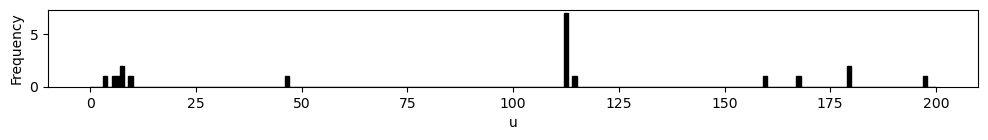

In [56]:
import matplotlib.pyplot as plt

def create_histogram(data, range_min, range_max, filename):
    fig, ax = plt.subplots(figsize=(12, 1))
    ax.hist(data, bins=200, range=(range_min, range_max), edgecolor='black', color='black')
    ax.set_xlabel('u')
    ax.set_ylabel('Frequency')
    plt.savefig(filename, format='svg')
    plt.show()

# Example usage
data = [159,
 7,
 112,
 112,
 112,
 112,
 3,
 46,
 114,
 112,
 6,
 5,
 7,
 167,
 112,
 9,
 197,
 179,
 179,
 112]
range_min = 0
range_max = 200
filename = 'histogram_u_param.svg'

create_histogram(data, range_min, range_max, filename)


In [72]:
def get_smallest_distances(distance_matrix, indices):
    smallest_distances = []
    for index1, index2 in combinations(indices, 2):
        distance = distance_matrix[index1][index2]
        smallest_distances.append(distance)
    return min(smallest_distances)



In [79]:
exp = Experiment("Observation cluster based - ED", df_test, features, w_var=50, d_var=3, q_var=50,
                  min_coverage = 0.001, normalization_var=percent_change_norm, min_coverage_abs = 3) # normalization_var=percentual_differences,
exp.prepare()

exp.df = exp.df.reset_index(drop=True)

In [66]:
bus = botumUpSearch(exp.df, euclidean_slope_distance_matrix, 500, 3, 500, nr_chunks=10, min_coverage_perc=0.01, min_coverage_abs=3)
bus.findQuality(quality_measure = cluster_based_quality_measure, comparison_type = "complement" , size_corr = no_size_corr)

promising_combinations_start step=  500
promising_combinations_mid step=  1000
promising_combinations_large=  439
descriptions 1317
unique descriptions 7651


In [71]:
bus.quals

[2.606619326304694,
 2.673147850164365,
 2.8338945991302036,
 2.7647207409569576,
 2.7511217990827412,
 2.8559918446121055,
 2.9404181515751087,
 2.7896764925929673,
 2.9200738970091984,
 2.9860819696901997,
 2.81986629675578,
 3.2318797601926534,
 3.0301886876782413,
 3.111288026450772,
 3.265731939983011,
 4.699067468718765,
 3.3041805926392023,
 3.129716790708374,
 2.9231141759006665,
 3.0178358236555836,
 3.414438861080801,
 4.800491899275426,
 2.9138038952004868,
 4.138167279709167,
 3.868556220577053,
 3.3603228561174396,
 3.3603228561174396,
 3.7148007578632734,
 3.12090631197858,
 4.780351104970723,
 3.612927512317995,
 6.544460533198541,
 6.03930134110328,
 4.59253397017006,
 3.881555073415839,
 4.173743670345925,
 3.7855659053952566,
 4.28395490040275,
 2.9860819696901997,
 3.7148007578632734,
 4.59253397017006,
 5.1672627700583895,
 4.321113018101877,
 5.036677726640027,
 4.891785623569393,
 3.041103182205407,
 5.98389415879227,
 5.755830951217805,
 4.4963646493111025,
 4.67

In [68]:
bus.descs

[["country == 'Australia'",
  '-3981.495 <= enterpriseToEbitda <= -12.213599999999998'],
 ["sector == 'Healthcare'",
  '-3981.495 <= enterpriseToEbitda <= -12.213599999999998'],
 ["sector == 'Financial Services'",
  '3091.0 <= averageVolume10days <= 15940.0'],
 ["country == 'Canada'"],
 ["country == 'United States'", "sector == 'Consumer Defensive'"],
 ["country == 'United States'",
  '22.007600000000004 <= debtToEquity <= 36.09500000000002'],
 ["country == 'United States'",
  '61310.499999999985 <= averageVolume10days <= 205434.00000000035'],
 ["sector == 'Real Estate'"],
 ["country == 'United States'",
  "currency == 'USD'",
  '61310.499999999985 <= averageVolume10days <= 205434.00000000035'],
 ["industry == 'Drug Manufacturers—Specialty & Generic'"],
 ['0.0 <= debtToEquity <= 2.442',
  '-3981.495 <= enterpriseToEbitda <= -12.213599999999998'],
 ['17497604.111792002 <= marketCap <= 60854265.99951998',
  "sector == 'Healthcare'"],
 ['24.745400000000004 <= enterpriseToEbitda <= 25860.8

In [69]:
bus.print_outcome()

after checking  655  potential subgroups, in  233.966  seconds
Outcome of bottumUpSearch is:
 
avg_quality =  11.973
max_quality =  47.521
 
avg_coverage =  0.029
max_coverage =  0.306
 
description = (country='United States') Ʌ (industry='Asset Management') Ʌ (exchange='NYQ')
quality = 47.521
coverage = 0.02
 
description = (exchangeTimezoneName='America/New_York') Ʌ (industry='Asset Management') Ʌ (exchange='NYQ')
quality = 47.301
coverage = 0.02
 
description = (sector='Financial Services') Ʌ (industry='Asset Management') Ʌ (exchange='NYQ')
quality = 47.301
coverage = 0.02
 
description = (industry='Asset Management') Ʌ (exchange='NYQ')
quality = 47.301
coverage = 0.02
 
description = (industry='Asset Management') Ʌ (exchange='NYQ') Ʌ (currency='USD')
quality = 47.301
coverage = 0.02
 
description = (sector='Financial Services') Ʌ (currency='USD') Ʌ (exchange='NYQ')
quality = 37.384
coverage = 0.03
 
description = (sector='Financial Services') Ʌ (exchange='NYQ')
quality = 37.384
cov

In [24]:
bus.descs

[["currency == 'EUR'",
  '59721.0 <= fullTimeEmployees <= 2300000.0',
  "exchange == 'FRA'"],
 ['131.653 <= debtToEquity <= 219.757',
  '7222688665.6 <= marketCap <= 24683085572.046852'],
 ['24683085572.046852 <= marketCap <= 1.0602763499077632e+16',
  "exchange == 'NYQ'"],
 ['24683085572.046852 <= marketCap <= 1.0602763499077632e+16',
  "currency == 'USD'",
  '59721.0 <= fullTimeEmployees <= 2300000.0'],
 ["currency == 'USD'",
  "exchangeTimezoneName == 'America/New_York'",
  '59721.0 <= fullTimeEmployees <= 2300000.0'],
 ["currency == 'USD'", '59721.0 <= fullTimeEmployees <= 2300000.0'],
 ["currency == 'EUR'", '59721.0 <= fullTimeEmployees <= 2300000.0'],
 ['131.653 <= debtToEquity <= 219.757',
  '11.3453 <= enterpriseToEbitda <= 15.523'],
 ['15.523 <= enterpriseToEbitda <= 24.745400000000004',
  "sector == 'Real Estate'"],
 ["country == 'United States'",
  "sector == 'Financial Services'",
  "exchange == 'NYQ'"],
 ["sector == 'Financial Services'",
  '7222688665.6 <= marketCap <= 24

## Reverse engineering

In [73]:
bus.quals
descs = bus.descs

In [83]:
bus.quals

500

In [80]:
import bisect
list_of_ranks = []

for desc in descs:
    value=get_smallest_distances(euclidean_slope_distance_matrix,exp.df[exp.df.eval(as_string(desc))].index)
    list_of_ranks.append(bisect.bisect_right(sorted_values, value)+1)
list_of_ranks

[1,
 404,
 111,
 14,
 55,
 112,
 220,
 34,
 220,
 251,
 152,
 136,
 94,
 157,
 41,
 271,
 41,
 13,
 1,
 10,
 287,
 199,
 220,
 51,
 38,
 220,
 220,
 271,
 157,
 49,
 287,
 78,
 136,
 37,
 197,
 271,
 326,
 365,
 251,
 271,
 37,
 166,
 17,
 62,
 220,
 27,
 5,
 175,
 271,
 340,
 223,
 305,
 291,
 1,
 62,
 483,
 45,
 220,
 157,
 57,
 54,
 14,
 232,
 45,
 208,
 13,
 55,
 271,
 278,
 4,
 54,
 305,
 271,
 323,
 136,
 271,
 198,
 199,
 271,
 14,
 157,
 136,
 78,
 233,
 69,
 25,
 271,
 7,
 428,
 278,
 86,
 64,
 138,
 403,
 7,
 195,
 55,
 69,
 41,
 483,
 271,
 199,
 86,
 148,
 157,
 3,
 80,
 49,
 55,
 223,
 5,
 13,
 83,
 152,
 80,
 28,
 1,
 483,
 199,
 89,
 271,
 45,
 136,
 4,
 18,
 14,
 45,
 95,
 1,
 51,
 368,
 5,
 3,
 198,
 4,
 7,
 220,
 19,
 65,
 86,
 388,
 320,
 11,
 45,
 216,
 14,
 45,
 287,
 271,
 83,
 3,
 10,
 18,
 278,
 138,
 271,
 136,
 41,
 271,
 308,
 17,
 278,
 28,
 7,
 86,
 55,
 179,
 7,
 40,
 140,
 11,
 54,
 51,
 11,
 308,
 2,
 278,
 28,
 233,
 278,
 220,
 57,
 271,
 7,
 3,
 175,


In [78]:
df_test

,country,sector,industry,exchangeTimezoneName,exchange,currency,debtToEquity,enterpriseToEbitda,averageVolume10days,fullTimeEmployees,marketCap,target
0,France,Industrials,Aerospace & Defense,Europe/Paris,PAR,EUR,50.783,11.822,382.0,1102.0,5.750674e+07,"[47.20000076293945, 47.75, 48.900001525878906,..."
1,Canada,Healthcare,Drug Manufacturers—Specialty & Generic,Europe/Berlin,FRA,EUR,NaN,-6.054,0.0,40.0,2.624033e+05,"[0.11999999731779099, 0.3190000057220459, 0.58..."
2,Germany,Technology,Software—Application,Europe/Berlin,GER,EUR,32.492,33.294,8329.0,650.0,1.241838e+09,"[37.70000076293945, 37.005001068115234, 43.299..."
3,Switzerland,Technology,Software—Application,Europe/Berlin,FRA,EUR,NaN,-0.387,7650.0,52.0,1.976241e+05,"[0.3199999928474426, 0.26499998569488525, 0.30..."
4,Germany,Industrials,Marine Shipping,Europe/Berlin,HAN,EUR,41.392,7.614,0.0,807.0,NaN,"[42.5, 44.5, 43.599998474121094, 47.0, 46.0, 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...
18508,Japan,Industrials,Electrical Equipment & Parts,Europe/London,LSE,JPY,10.654,6.287,4893.0,145696.0,2.079737e+10,"[1852.5, 1872.576171875, 2068.0, 1825.0, 1621...."
18509,Japan,Industrials,Business Equipment & Supplies,Europe/London,LSE,JPY,35.268,5.531,1940.0,78360.0,5.086319e+09,"[996.0, 1054.0, 1072.0, 1156.0, 1034.0, 1071.0..."
18510,Japan,Communication Services,Electronic Gaming & Multimedia,Europe/London,LSE,JPY,18.311,7.976,3530.0,4894.0,6.297095e+09,"[5930.0, 6315.5048828125, 6315.5048828125, 563..."
18511,Japan,Technology,Electronic Components,Europe/London,LSE,JPY,1.943,7.200,350.0,1297.0,1.774490e+09,"[7000.09521484375, 7000.09521484375, 7000.0952..."


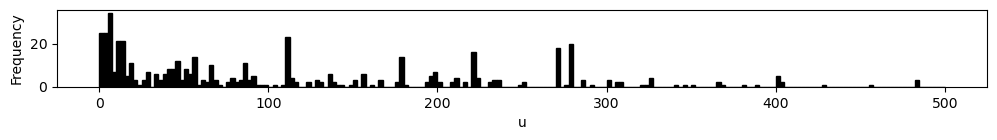

In [94]:
import matplotlib.pyplot as plt

def create_histogram(data, range_min, range_max, filename):
    fig, ax = plt.subplots(figsize=(12, 1))
    ax.hist(data, bins=200, range=(range_min, range_max), edgecolor='black', color='black')
    ax.set_xlabel('u')
    ax.set_ylabel('Frequency')
    plt.savefig(filename, format='svg')
    plt.show()

# Example usage
data = list_of_ranks
range_min = 0
range_max = 500
filename = 'histogram_u_param_500.svg'

create_histogram(data, range_min, range_max, filename)

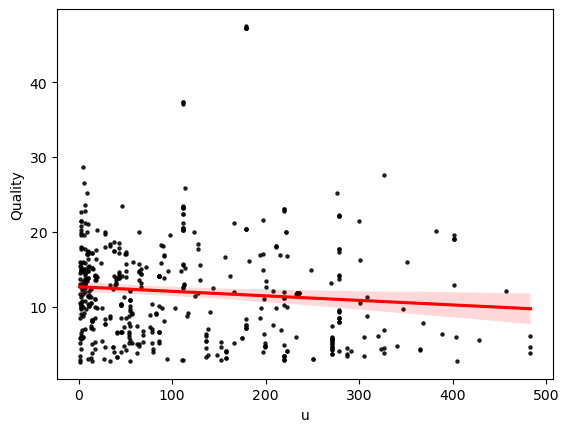

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt
# Assuming you have x and y data
# Replace x and y with your actual data
x, y = list_of_ranks, bus.quals

x, y = list_of_ranks, bus.quals

# Create the scatter plot with linear regression line
sns.regplot(x, y, color='black', scatter_kws={'s': 5}, line_kws={'color': 'red'})

# Add labels and title
plt.xlabel('u')
plt.ylabel('Quality')
filename = 'relationUandQuality.svg'

# Find the index of the point with the highest quality
index_highest_quality = y.index(max(y))

# Annotate the point with the highest quality and u > 300
for i in range(len(x)):
    if x[i] > 300 and y[i] == max(y):
        plt.annotate(f'Highest Quality: {max(y):.2f}', xy=(x[i], y[i]), xytext=(x[i], y[i]+10),
                     arrowprops=dict(facecolor='black', arrowstyle='->'))
        break

# Save the plot as SVG
plt.savefig(filename, format='svg')

# Show the plot
plt.show()



### Comparison to Beam Search

In [18]:
outputEMM = EMM(exp_test.df, features, w=50, d=3, q=20, quality_measure=cluster_based_quality_measure, catch_all_description=[],                
        comparison_type = 'complement',target='target', n_chunks=5, ensure_diversity=True,
        report_progress=False, allow_exclusion=False, min_coverage = 0.01,
                          min_coverage_abs = 3, min_error = 0.01,distance_matrix=distance_matrix,correct_for_size=no_size_corr)

level :  0
    seed :  []
0 / 3 queue= 1 / 1
eta  []
level :  1
    seed :  ["averageVolume10days == '205434.00000000035 <= averageVolume10days <= 824162.0000000006'"]
1 / 3 queue= 1 / 50
eta  ["averageVolume10days == '205434.00000000035 <= averageVolume10days <= 824162.0000000006'"]
    seed :  ["currency == 'CAD'"]
1 / 3 queue= 2 / 50
eta  ["currency == 'CAD'"]
    seed :  ["exchangeTimezoneName == 'America/Toronto'"]
1 / 3 queue= 3 / 50
eta  ["exchangeTimezoneName == 'America/Toronto'"]
    seed :  ["industry == 'Specialty Industrial Machinery'"]
1 / 3 queue= 4 / 50
eta  ["industry == 'Specialty Industrial Machinery'"]
    seed :  ["debtToEquity == '93.854 <= debtToEquity <= 131.653'"]
1 / 3 queue= 5 / 50
eta  ["debtToEquity == '93.854 <= debtToEquity <= 131.653'"]
    seed :  ["sector == 'Utilities'"]
1 / 3 queue= 6 / 50
eta  ["sector == 'Utilities'"]
    seed :  ["debtToEquity == '50.86 <= debtToEquity <= 70.049'"]
1 / 3 queue= 7 / 50
eta  ["debtToEquity == '50.86 <= debtToEquity 

    seed :  ["debtToEquity == '50.86 <= debtToEquity <= 70.049'", "exchange == 'NYQ'"]
2 / 3 queue= 11 / 50
eta  ["debtToEquity == '50.86 <= debtToEquity <= 70.049'", "exchange == 'NYQ'"]
    seed :  ["exchange == 'NYQ'", "debtToEquity == '50.86 <= debtToEquity <= 70.049'"]
2 / 3 queue= 12 / 50
eta  ["exchange == 'NYQ'", "debtToEquity == '50.86 <= debtToEquity <= 70.049'"]
    seed :  ["fullTimeEmployees == '21760.0 <= fullTimeEmployees <= 59721.0'", "averageVolume10days == '824162.0000000006 <= averageVolume10days <= 489560408.0'"]
2 / 3 queue= 13 / 50
eta  ["fullTimeEmployees == '21760.0 <= fullTimeEmployees <= 59721.0'", "averageVolume10days == '824162.0000000006 <= averageVolume10days <= 489560408.0'"]
    seed :  ["exchange == 'FRA'", "fullTimeEmployees == '21760.0 <= fullTimeEmployees <= 59721.0'"]
2 / 3 queue= 14 / 50
eta  ["exchange == 'FRA'", "fullTimeEmployees == '21760.0 <= fullTimeEmployees <= 59721.0'"]
    seed :  ["fullTimeEmployees == '21760.0 <= fullTimeEmployees <= 59

    seed :  ["fullTimeEmployees == '59721.0 <= fullTimeEmployees <= 2300000.0'", "country == 'France'"]
2 / 3 queue= 47 / 50
eta  ["fullTimeEmployees == '59721.0 <= fullTimeEmployees <= 2300000.0'", "country == 'France'"]
    seed :  ["exchange == 'NYQ'", "averageVolume10days == '15940.0 <= averageVolume10days <= 61310.499999999985'"]
2 / 3 queue= 48 / 50
eta  ["exchange == 'NYQ'", "averageVolume10days == '15940.0 <= averageVolume10days <= 61310.499999999985'"]
    seed :  ["exchange == 'NYQ'", "sector == 'Financial Services'"]
2 / 3 queue= 49 / 50
eta  ["exchange == 'NYQ'", "sector == 'Financial Services'"]
    seed :  ["exchange == 'NYQ'", "industry == 'Asset Management'"]
2 / 3 queue= 50 / 50
eta  ["exchange == 'NYQ'", "industry == 'Asset Management'"]
We checked  868  subgroups


In [23]:
def analyseEMMresults(outputEMM):
    EMM_results = outputEMM.values

    result = sorted(EMM_results, key=lambda x: x[0], reverse=True)

    quals = [i[0] for i in result]
    covs = [i[1] for i in result]
    avg_quality = sum(quals)/len(quals)
    avg_coverage = sum(covs)/len(covs)
    descs = [i[3] for i in result]

    print('Outcome of EMM is:')
    print(' ')
    print('avg_quality = ',round(avg_quality,3))
    print('max_quality = ',round(max(quals),3))
    print(' ')
    print('avg_coverage = ',round(avg_coverage,3))
    print('max_coverage = ',round(max(covs),3))
    print(' ')

    for z in result:
        conjunction = " Ʌ ".join(["(" + condition.replace(" == ", "=").strip() + ")" for condition in z[3]])
        print('description =',conjunction)
        print('quality =',round(z[0],3))
        print('coverage =',round(z[1],3))
        print(' ')
analyseEMMresults(outputEMM)


Outcome of EMM is:
 
avg_quality =  30.109
max_quality =  47.521
 
avg_coverage =  0.017
max_coverage =  0.03
 
description = (exchange='NYQ') Ʌ (country='United States') Ʌ (industry='Asset Management')
quality = 47.521
coverage = 0.02
 
description = (exchange='NYQ') Ʌ (industry='Asset Management')
quality = 47.301
coverage = 0.02
 
description = (exchange='NYQ') Ʌ (sector='Financial Services') Ʌ (industry='Asset Management')
quality = 47.301
coverage = 0.02
 
description = (exchange='NYQ') Ʌ (sector='Financial Services')
quality = 37.384
coverage = 0.03
 
description = (exchange='NYQ') Ʌ (country='United States') Ʌ (sector='Financial Services')
quality = 37.148
coverage = 0.028
 
description = (exchange='NYQ') Ʌ (country='United States') Ʌ (averageVolume10days='15940.0 <= averageVolume10days <= 61310.499999999985')
quality = 31.307
coverage = 0.01
 
description = (exchange='NYQ') Ʌ (averageVolume10days='15940.0 <= averageVolume10days <= 61310.499999999985')
quality = 30.537
coverage 